In [1]:
import os,sys
import numpy as np
import configparser
import matplotlib.pyplot as plt
import matplotlib
import argparse
from psana import DataSource
from numba import jit, njit
import scipy.ndimage.measurements as smt
sys.path.append('/sdf/data/lcls/ds/ued_testfac/scratch/python_packages')
from ued_LCLSII_DAQ_utilities import *
from UEDePixTools import *
from tqdm import tqdm
from PIL import Image
from matplotlib.colors import LogNorm
# %matplotlib widget

In [2]:
# exp and run infor and load raw data using LCLS DataSource
exp = 'ued1015999'  # experiment
run = 115 # charge scan of Al on the 
# max_events = num_steps*1080 # how many shots to load
max_events = 540*16 # how many shots to load
ds     = DataSource(exp=exp, run=run, max_events=max_events) # Load .xtc using DataSource, normal experiment and run
# ds     = DataSource(exp=exp, run=run) # Load .xtc using DataSource, normal experiment and run
myrun  = next(ds.runs()) # Load runs
if 1 == 1: # the scanning PVs
    scan_motor = 'UED:USR:MMN:14:01' # scanning stage
    step_v = myrun.Detector(scan_motor) # Load stage position
epix   = myrun.Detector('epixquad1kfps') # Detector
evt    = next(myrun.events()) # event
steps  = myrun.steps() 

In [3]:
# Define some trial peak finding parameters
max_electrons = 1000 # Max number of electrons the peakFinder allowed to find
threshold     = 40    # Threshold for peak finding, pixel intensity below this is filtered
min_signal    = 100   # Min intensity to be considered as electron signal
# delete the dataSource to obtain the new DataSource
try:
    ds  # Try to access the variable
    print("ds exists!")
    print("ds deleted!")
    del ds
except NameError:
    print("ds does not exist.")

ds exists!
ds deleted!


In [4]:
# Running the peak finding
beamCenter = np.array([397,309]) # set the center manually if needed
calib_evts     = [] # Modules of each evt
img_raw_evts   = [] # Raw images
x_evts         = [] # Peak X coordinates
y_evts         = [] # Peak Y coordinates
Intensity_evts = [] # Peak intensities
Size_evts      = [] # Peak pixel size
n_peaks_evts   = [] #
step_evts      = [] # Delay stage position

# --- NEW: choose the window of events you actually want ---
#start_event = 0   # first event to process, dense
start_event = 0   # first event to process, sparse
end_event   = start_event + 250   # last event to process (exclusive)

# Load the data from xtc files
exp = 'ued1015999'  # experiment

#run = 115 # charge scan of Al on the
run = 125

# max_events must be high enough to REACH your window
ds     = DataSource(exp=exp, run=run, max_events=end_event) # only pull up to end_event
myrun  = next(ds.runs()) # Load runs
epix   = myrun.Detector('epixquad1kfps')

evt_count = 0 # Counter of the event
for evt in myrun.events():
    # --- NEW: skip the early events cheaply (no calib/blobCounter) ---
    if evt_count < start_event:
        evt_count += 1
        continue
    # --- NEW: stop once we pass the window ---
    if evt_count >= end_event:
        break

    calib = epix.raw.calib(evt)
    if calib is None: # this can return none, skip if it does
        evt_count += 1        # <-- keep counter consistent even on skips
        continue
    evt_count = evt_count + 1
    if evt_count % 100 == 0:
        print('Looking at evt # ' + str(evt_count))

    # define output arrays for peaks then populate them
    n_peaks = np.zeros(calib.shape[0])
    x = np.zeros((calib.shape[0], max_electrons))
    y = np.zeros((calib.shape[0], max_electrons))
    intensities = np.zeros((calib.shape[0], max_electrons))
    sizes = np.zeros((calib.shape[0], max_electrons))

    # The peakFinding algorithm
    for i, module in enumerate(calib): # loop the number of quadrants
        n, _x, _y, _ints, _sizes = blobCounter(module, threshold, min_signal)
        n_peaks[i] = n
        if n > max_electrons:
            x[i] = _x[:max_electrons]
            y[i] = _y[:max_electrons]
            intensities[i] = _ints[:max_electrons]
            sizes[i] = _sizes[:max_electrons]
        else:
            x[i][:n] = _x
            y[i][:n] = _y
            intensities[i][:n] = _ints
            sizes[i][:n] = _sizes
    step_evts.append(step_v(evt))
    calib_evts.append(calib)
    x_evts.append(x)
    y_evts.append(y)
    Intensity_evts.append(intensities)
    Size_evts.append(sizes)
    n_peaks_evts.append(n_peaks)
    img_raw_evts.append(epix.raw.image(evt,calib))

x_evts = np.array(x_evts)
y_evts = np.array(y_evts)
Intensity_evts = np.array(Intensity_evts)
Size_evts = np.array(Size_evts)
n_peaks_evts = np.array(n_peaks_evts)
step_evts = np.array(step_evts)
print(str(len(x_evts)) + ' evts processed (from window ' 
      + str(start_event) + ' to ' + str(end_event) + ')')
print('Finish peak finding')
print('Delays are:' + str(np.unique(step_evts)))

Looking at evt # 100
Looking at evt # 200
250 evts processed (from window 0 to 250)
Finish peak finding
Delays are:[49.99975]


In [5]:
np.save('catalog/Intensity_evts_run_'+str(run)+'_pedestal.npy', Intensity_evts)

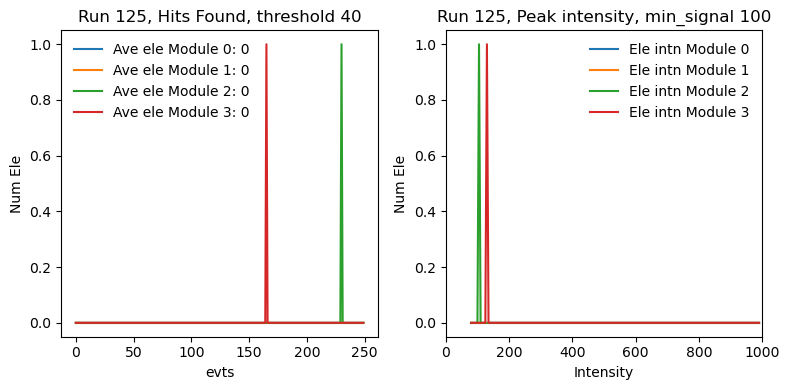

In [6]:
# Plot the results of trial peakFinding results
# Plot the number of peaks found at each quad
# plot number of electron found per shot
NumEle = np.count_nonzero(x_evts,axis=2)
fig, axes = plt.subplots(1,2,figsize=(8, 4))
# cmapLim = [0,100]
for i_mdl in range(4):
     axes[0].plot(NumEle[:,i_mdl],label=r"Ave ele Module %i: %i"%(i_mdl,np.mean(NumEle[:,i_mdl])))
axes[0].legend(framealpha=0)
axes[0].set_xlabel('evts');axes[0].set_ylabel('Num Ele');axes[0].set_title('Run '+str(run)+', Hits Found, threshold '+str(threshold));

bins_intn=np.arange(80,1000,5)
for i_mdl in range(4):
    hist_intn, bin_edges = np.histogram(Intensity_evts[:,i_mdl,:].flatten(), bins = bins_intn)
    axes[1].plot(bin_edges[0:-1],hist_intn,label=r"Ele intn Module %i"%(i_mdl))
axes[1].legend(framealpha=0)
axes[1].set_xlabel('Intensity');axes[1].set_ylabel('Num Ele');axes[1].set_title('Run '+str(run)+', Peak intensity, min_signal '+str(min_signal));
plt.xlim([0,1000])
plt.tight_layout()
plt.show()

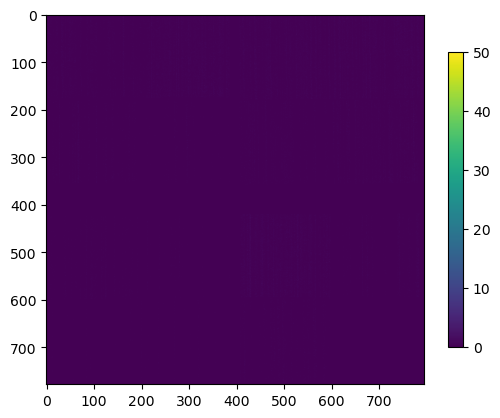

In [7]:
img_sgl = img_raw_evts[0] # Check one image
plt.imshow(np.transpose(img_sgl),cmap = 'viridis', vmin=0,vmax=50);plt.colorbar(shrink=0.8)

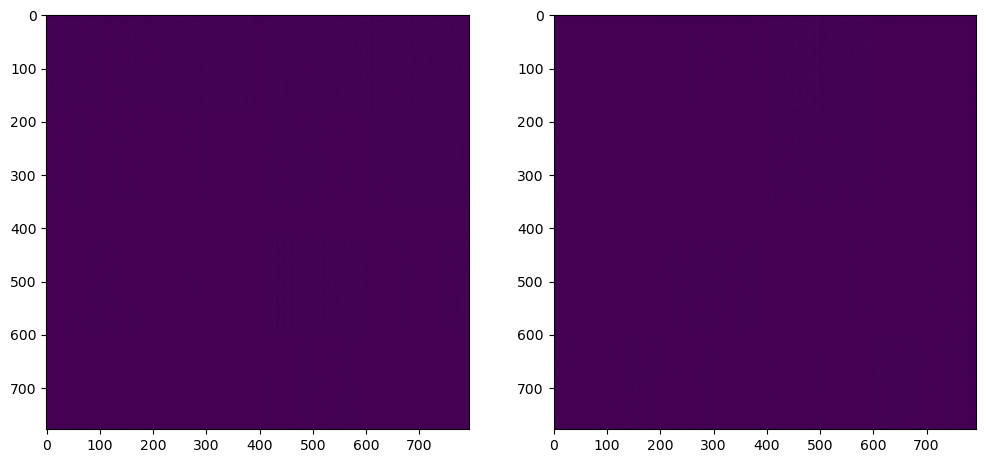

In [8]:
fig,ax = plt.subplots(1,2,figsize=(12,8))
ax = ax.flatten()
for i in range(2):
    ax[i].imshow(np.transpose(img_raw_evts[i]),cmap = 'viridis', vmin=0,vmax=50)

In [10]:
type(img_raw_evts[0])

numpy.ndarray

In [12]:
pixel_std = np.std(img_raw_evts,axis=0)

Text(0.5, 1.0, 'Standard Deviation of DARK ePix pixels')

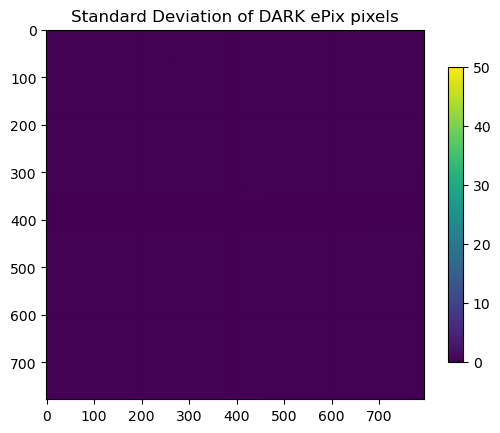

In [26]:
plt.imshow(np.transpose(pixel_std),cmap = 'viridis', vmin=0,vmax=50);
plt.colorbar(shrink=0.8)
plt.title("Standard Deviation of DARK ePix pixels")

Text(0.5, 1.0, 'Standard Deviation of DARK ePix pixels (Run 125)')

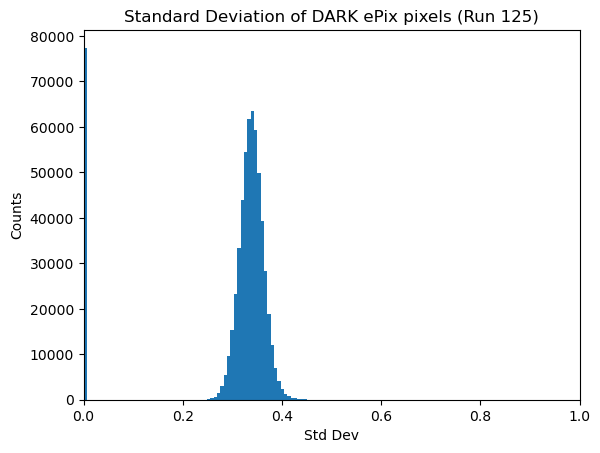

In [25]:
plt.hist(pixel_std.flatten(),bins=1000)
plt.xlim(0,1);
plt.xlabel("Std Dev")
plt.ylabel("Counts")
plt.title("Standard Deviation of DARK ePix pixels (Run 125)")

In [23]:
max(pixel_std.flatten())

6.728223